# BAG OF WORDS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.procesamiento_corpus.preprocesamiento import cargar_y_preparar_corpus
from src.modelos_analisis_semantico.bagOFwords import (
    construir_bow, construir_tfidf, top_terminos_tfidf, matriz_similitud_documentos,
)

## CARGA DEL CORPUS

In [3]:
corpus = cargar_y_preparar_corpus()
corpus[["lugar", "categoria", "calificacion", "tokens"]].head()

,lugar,categoria,calificacion,tokens
0,Playa Manuel Antonio,parque,5.0,"[playa, manuel, antonio, absolutamente, impres..."
1,Playa Manuel Antonio,parque,5.0,"[dos, playa, separado, parque, nacional, manue..."
2,Playa Manuel Antonio,parque,5.0,"[playa, excepcional, sólo, acceder, pagar, ent..."
3,Playa Manuel Antonio,parque,5.0,"[cualquiera, turista, incluso, local, mab, inc..."
4,Playa Manuel Antonio,parque,4.0,"[bonita, playa, bonito, país, gente, encontrar..."


## TF-IDF

In [1]:
matriz_tfidf, vectorizer = construir_tfidf(corpus["tokens"])
print(f"Matriz TF-IDF: {matriz_tfidf.shape} (reseñas x vocabulario)")
print(f"Tamaño del vocabulario: {len(vectorizer.get_feature_names_out())}")

NameError: name 'construir_tfidf' is not defined

In [6]:
matriz_bow, vectorizer_bow = construir_bow(corpus["tokens"])
print(f"Matriz BoW: {matriz_bow.shape}")


Matriz BoW: (2402, 2569)


## PESOS DE LAS PALABRAS

In [8]:
for categoria in corpus["categoria"].unique():
    idx_categoria = corpus.index[corpus["categoria"] == categoria].tolist()
    idx_categoria_pos = [corpus.index.get_loc(i) for i in idx_categoria]
    print(f"\n=== {categoria.upper()} ===")
    for termino, peso in top_terminos_tfidf(matriz_tfidf, vectorizer, idx_categoria_pos):
        print(f"  {termino}: {peso:.4f}")



=== PARQUE ===
  playa: 0.1230
  lugar: 0.0442
  hermoso: 0.0423
  agua: 0.0409
  cascada: 0.0360
  parque: 0.0325
  nadar: 0.0292
  pena: 0.0265
  bonito: 0.0263
  ver: 0.0261
  valer: 0.0254
  mejor: 0.0237
  gente: 0.0230
  tener: 0.0209
  escalón: 0.0209

=== RESTAURANTE ===
  comida: 0.1285
  buen: 0.0741
  servicio: 0.0547
  precio: 0.0483
  lugar: 0.0442
  excelente: 0.0437
  rico: 0.0394
  ambiente: 0.0340
  deliciós: 0.0335
  mejor: 0.0279
  gran: 0.0271
  variedad: 0.0242
  tener: 0.0238
  atención: 0.0232
  restaurante: 0.0212

=== ALOJAMIENTO ===
  habitación: 0.0574
  personal: 0.0481
  jardín: 0.0445
  piscina: 0.0411
  hermoso: 0.0401
  desayuno: 0.0400
  hotel: 0.0381
  ubicación: 0.0370
  bien: 0.0333
  tener: 0.0329
  amable: 0.0328
  volcán: 0.0305
  limpio: 0.0304
  excelente: 0.0298
  vista: 0.0281


In [9]:
import pandas as pd


muestra = pd.concat([
    grupo.sample(min(5, len(grupo)), random_state=42)
    for _, grupo in corpus.groupby("categoria")
]).reset_index(drop=True)

print(f"Muestra: {len(muestra)} reseñas ({muestra['categoria'].value_counts().to_dict()})")

Muestra: 15 reseñas ({'alojamiento': 5, 'parque': 5, 'restaurante': 5})


## MATRIZ DE SIMILITUD

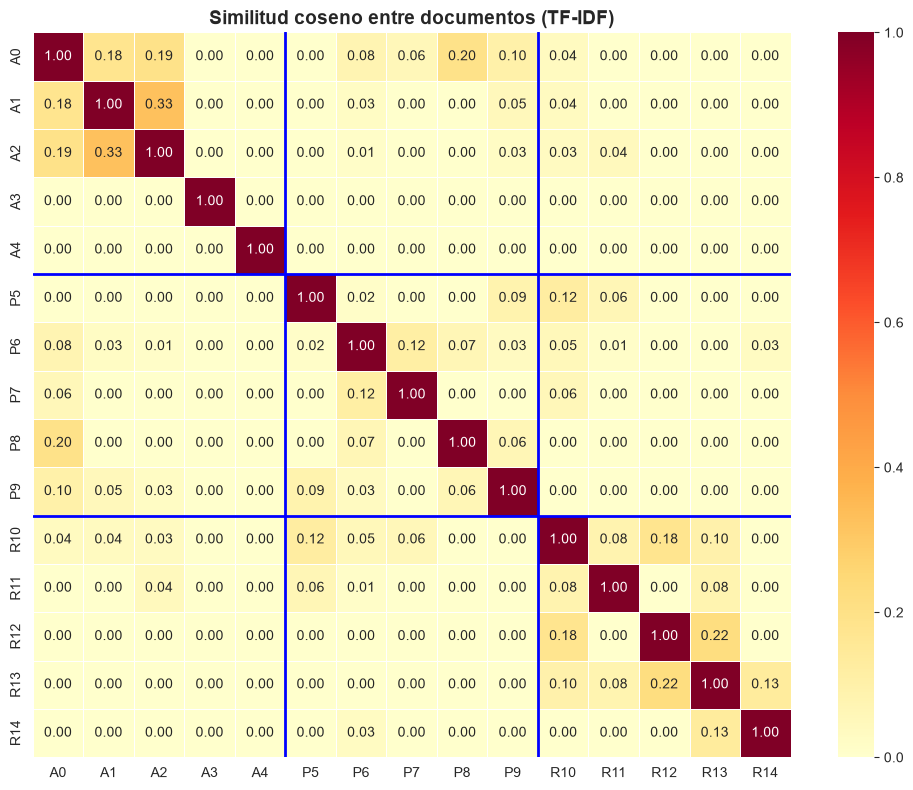

P=Parque, R=Restaurante, A=Alojamiento


In [12]:
matriz_tfidf_muestra, _ = construir_tfidf(muestra["tokens"], min_df=1)
sim_tfidf = matriz_similitud_documentos(matriz_tfidf_muestra)

etiquetas = [f"{cat[0].upper()}{i}" for i, cat in enumerate(muestra["categoria"])]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_tfidf, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=etiquetas, yticklabels=etiquetas,
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Similitud coseno entre documentos (TF-IDF)", fontsize=14, fontweight="bold")

for pos in range(5, len(muestra), 5):
    ax.axhline(y=pos, color="blue", linewidth=2)
    ax.axvline(x=pos, color="blue", linewidth=2)

plt.tight_layout()
plt.show()

print("P=Parque, R=Restaurante, A=Alojamiento")

In [13]:
corpus = cargar_y_preparar_corpus()
corpus[["lugar", "categoria", "calificacion", "tokens"]].head()

,lugar,categoria,calificacion,tokens
0,Playa Manuel Antonio,parque,5.0,"[playa, manuel, antonio, absolutamente, impres..."
1,Playa Manuel Antonio,parque,5.0,"[dos, playa, separado, parque, nacional, manue..."
2,Playa Manuel Antonio,parque,5.0,"[playa, excepcional, sólo, acceder, pagar, ent..."
3,Playa Manuel Antonio,parque,5.0,"[cualquiera, turista, incluso, local, mab, inc..."
4,Playa Manuel Antonio,parque,4.0,"[bonita, playa, bonito, país, gente, encontrar..."


In [12]:
matriz_tfidf, vectorizer = construir_tfidf(corpus["tokens"])
print(f"Matriz TF-IDF: {matriz_tfidf.shape} (reseñas x vocabulario)")
print(f"Tamaño del vocabulario: {len(vectorizer.get_feature_names_out())}")

Matriz TF-IDF: (1205, 1922) (reseñas x vocabulario)
Tamaño del vocabulario: 1922


In [13]:
matriz_bow, vectorizer_bow = construir_bow(corpus["tokens"])
print(f"Matriz BoW: {matriz_bow.shape}")

Matriz BoW: (1205, 1922)


In [14]:
for categoria in corpus["categoria"].unique():
    idx_categoria = corpus.index[corpus["categoria"] == categoria].tolist()
    idx_categoria_pos = [corpus.index.get_loc(i) for i in idx_categoria]
    print(f"\n=== {categoria.upper()} ===")
    for termino, peso in top_terminos_tfidf(matriz_tfidf, vectorizer, idx_categoria_pos):
        print(f"  {termino}: {peso:.4f}")



=== PARQUE ===
  playa: 0.1070
  hermoso: 0.0518
  lugar: 0.0419
  agua: 0.0386
  cascada: 0.0332
  parque: 0.0323
  bonito: 0.0302
  nadar: 0.0270
  ver: 0.0267
  pena: 0.0253
  valer: 0.0240
  mejor: 0.0236
  tener: 0.0228
  gente: 0.0217
  hermosa: 0.0209

=== RESTAURANTE ===
  comida: 0.1101
  buen: 0.0773
  servicio: 0.0509
  excelente: 0.0491
  precio: 0.0470
  lugar: 0.0429
  rico: 0.0381
  ambiente: 0.0338
  deliciós: 0.0320
  gran: 0.0291
  mejor: 0.0271
  tener: 0.0258
  variedad: 0.0235
  atención: 0.0234
  restaurante: 0.0223

=== ALOJAMIENTO ===
  habitación: 0.0802
  hotel: 0.0775
  piscina: 0.0592
  personal: 0.0425
  termal: 0.0420
  tener: 0.0391
  desayuno: 0.0384
  agua: 0.0372
  bien: 0.0343
  buen: 0.0321
  lugar: 0.0320
  restaurante: 0.0316
  amable: 0.0291
  servicio: 0.0267
  noche: 0.0248


In [15]:
muestra = pd.concat([
    grupo.sample(min(5, len(grupo)), random_state=42)
    for _, grupo in corpus.groupby("categoria")
]).reset_index(drop=True)

print(f"Muestra: {len(muestra)} reseñas ({muestra['categoria'].value_counts().to_dict()})")

Muestra: 15 reseñas ({'alojamiento': 5, 'parque': 5, 'restaurante': 5})


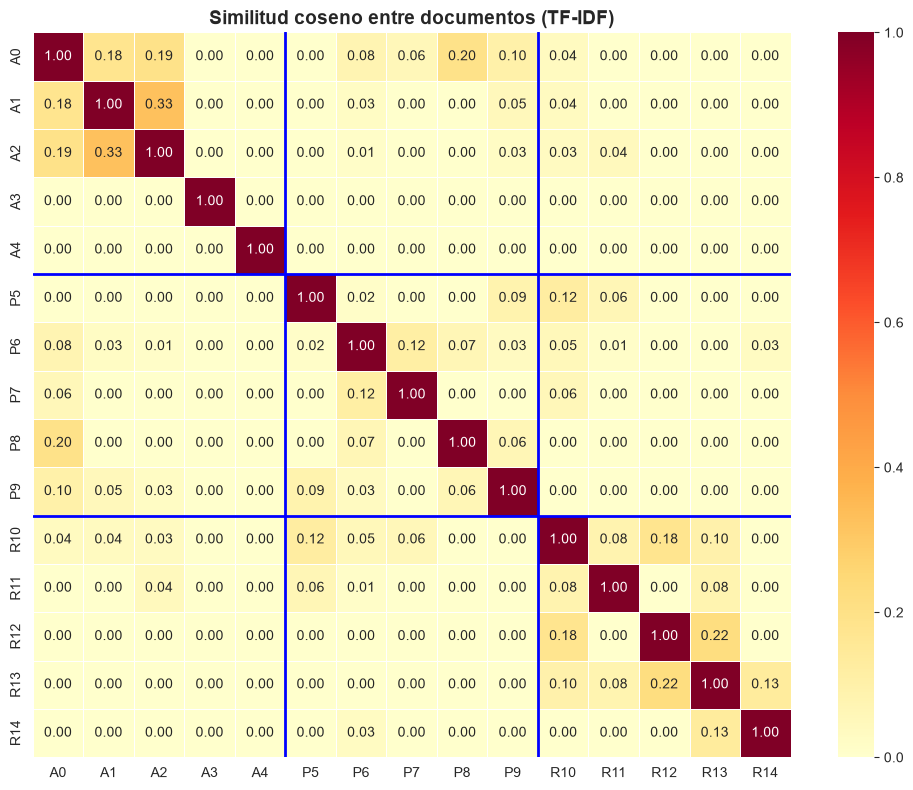

P=Parque, R=Restaurante, A=Alojamiento


In [20]:
matriz_tfidf_muestra, _ = construir_tfidf(muestra["tokens"], min_df=1)
sim_tfidf = matriz_similitud_documentos(matriz_tfidf_muestra)

etiquetas = [f"{cat[0].upper()}{i}" for i, cat in enumerate(muestra["categoria"])]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_tfidf, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=etiquetas, yticklabels=etiquetas,
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Similitud coseno entre documentos (TF-IDF)", fontsize=14, fontweight="bold")

for pos in range(5, len(muestra), 5):
    ax.axhline(y=pos, color="blue", linewidth=2)
    ax.axvline(x=pos, color="blue", linewidth=2)

plt.tight_layout()
plt.show()

print("P=Parque, R=Restaurante, A=Alojamiento")